# Pipeline Adaptive Threshold Comparison

This notebook runs the full raw-data walk-forward pipeline across multiple daily-threshold policies and compares the results side by side.

Policies:
- `static`
- `adaptive_reward`
- `adaptive_accuracy`
- `threshold_pair_bandit`


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

from adaptive_threshold_raw_walkforward import run_raw_adaptive_threshold_walkforward
from adaptive_trade_extensions import RollingThresholdConfig, ThresholdPairBanditConfig, make_threshold_grid

In [2]:
# ------------------------------------------------------------
# Shared base configuration for all policies
# ------------------------------------------------------------

base_kwargs = dict(
    daily_csv_path='DataAPI/data/QQQ_DAY.csv',
    k5m_csv_path='DataAPI/data/QQQ_5M.csv',
    code='QQQ',

    daily_chan_start='2016-06-01',
    accumulation_start='2018-10-01',
    sim_start='2024-01-01',
    end_time='2026-12-31',

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,
    five_chan_max_klines=500,

    macro_files={
        'vix_': 'VIX.csv',
        # 'dxy_': 'DXY.csv',
        # 'us5y_': 'US5Y.csv',
        # 'us10y_': 'US10Y.csv',
        # 'us30y_': 'US30Y.csv',
        # 'xau_': 'XAU.csv',
        # 'nyxbt_': 'NYXBT.csv',
        # '10y2ys_': '10Y2YS.csv',
        # 'us2y_': 'US2Y.csv',
        # 'spgsci_': 'SPGSCI.csv',
        # 'spy_': 'SPY_DAY.csv',
        # 'qqq_': 'QQQ_DAY.csv',
        # 'rut_': 'RUT.csv',
        # 'vvix_': 'VVIX.csv',
        # 'vix3m_': 'VIX3M.csv',
        # 'vxn_': 'VXN.csv',
        # 'rvx_': 'RVX.csv',
        # 'ixic_': 'IXIC.csv',
        # 'ndx_': 'NDX.csv',
        # 'dji_': 'DJI.csv',
    },

    static_buy_level=0.20,
    static_sell_level=0.30,

    daily_threshold_config=RollingThresholdConfig(
        lookback_days=252,
        buy_grid=make_threshold_grid(0.05, 0.35, 0.005),
        sell_grid=make_threshold_grid(0.15, 0.60, 0.005),
        min_gap=0.02,
        min_obs=60,
        switch_penalty=0.0,
    ),

    threshold_pair_bandit_config=ThresholdPairBanditConfig(
        threshold_pairs=[
            (0.10, 0.22),
            (0.12, 0.24),
            (0.15, 0.25),
            (0.18, 0.28),
            (0.20, 0.30),
            (0.22, 0.32),
            (0.25, 0.35),
        ],
        alpha=0.50,
        l2=1.0,
    ),

    verbose=True,
)

policies = ['static', 'adaptive_reward', 'adaptive_accuracy', 'threshold_pair_bandit']
policies

['static', 'adaptive_reward', 'adaptive_accuracy', 'threshold_pair_bandit']

In [3]:
# ------------------------------------------------------------
# Run all policies
# ------------------------------------------------------------

results = {}

for policy in policies:
    print('\n' + '=' * 100)
    print(f'Running policy: {policy}')
    print('=' * 100)
    kwargs = dict(base_kwargs)
    kwargs['policy_mode'] = policy
    kwargs['output_dir'] = f'output_raw_adaptive_threshold_compare_{policy}_QQQ'
    results[policy] = run_raw_adaptive_threshold_walkforward(**kwargs)

list(results.keys())


Running policy: static
[TRAIN][DAILY-PROB] n=200 pos=29 (14.50%)
[TRAIN][DAILY-PROB] n=225 pos=31 (13.78%)
[TRAIN][DAILY-PROB] n=250 pos=38 (15.20%)
[TRAIN][DAILY-PROB] n=275 pos=41 (14.91%)
[TRAIN][DAILY-PROB] n=300 pos=44 (14.67%)
[TRAIN][DAILY-PROB] n=325 pos=48 (14.77%)
[TRAIN][DAILY-PROB] n=350 pos=55 (15.71%)
[TRAIN][DAILY-PROB] n=375 pos=62 (16.53%)
[TRAIN][DAILY-PROB] n=400 pos=69 (17.25%)
[TRAIN][DAILY-PROB] n=425 pos=70 (16.47%)
[TRAIN][DAILY-PROB] n=450 pos=75 (16.67%)
[TRAIN][DAILY-PROB] n=475 pos=78 (16.42%)
[TRAIN][DAILY-PROB] n=500 pos=84 (16.80%)
[TRAIN][DAILY-PROB] n=525 pos=95 (18.10%)
[TRAIN][DAILY-PROB] n=550 pos=110 (20.00%)
[TRAIN][DAILY-PROB] n=575 pos=119 (20.70%)
[TRAIN][DAILY-PROB] n=600 pos=120 (20.00%)
[TRAIN][DAILY-PROB] n=625 pos=121 (19.36%)
[TRAIN][DAILY-PROB] n=650 pos=128 (19.69%)
[TRAIN][DAILY-PROB] n=675 pos=136 (20.15%)
[TRAIN][DAILY-PROB] n=700 pos=141 (20.14%)
[TRAIN][DAILY-PROB] n=725 pos=148 (20.41%)
[TRAIN][DAILY-PROB] n=750 pos=151 (20.13%)
[

['static', 'adaptive_reward', 'adaptive_accuracy', 'threshold_pair_bandit']

In [4]:
# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary_rows = []
for policy, res in results.items():
    daily_df = res['daily_log_df']
    reward_df = res['daily_reward_df']
    trades_df = res['trades_df']

    final_equity = float(daily_df['equity'].iloc[-1]) if not daily_df.empty else float('nan')
    reward_days = len(reward_df)
    trades = len(trades_df)
    avg_chosen_reward = float(reward_df['chosen_reward'].mean()) if ('chosen_reward' in reward_df.columns and not reward_df.empty) else float('nan')
    avg_oracle_reward = float(
        reward_df[['reward_force_buy', 'reward_free', 'reward_force_sell']].max(axis=1).mean()
    ) if not reward_df.empty else float('nan')

    summary_rows.append({
        'policy': policy,
        'final_equity': final_equity,
        'reward_days': reward_days,
        'num_trades': trades,
        'avg_chosen_reward': avg_chosen_reward,
        'avg_oracle_reward': avg_oracle_reward,
        'output_dir': res['output_dir'],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('final_equity', ascending=False).reset_index(drop=True)
summary_df

,policy,final_equity,reward_days,num_trades,avg_chosen_reward,avg_oracle_reward,output_dir
0,adaptive_reward,298886.437187,1886,416,0.000479,0.001414,output_raw_adaptive_threshold_compare_adaptive...
1,adaptive_accuracy,278162.223511,1886,256,0.000418,0.001479,output_raw_adaptive_threshold_compare_adaptive...
2,static,223994.476473,1886,902,0.000352,0.001322,output_raw_adaptive_threshold_compare_static_QQQ
3,threshold_pair_bandit,193105.414662,1886,850,0.000334,0.001342,output_raw_adaptive_threshold_compare_threshol...


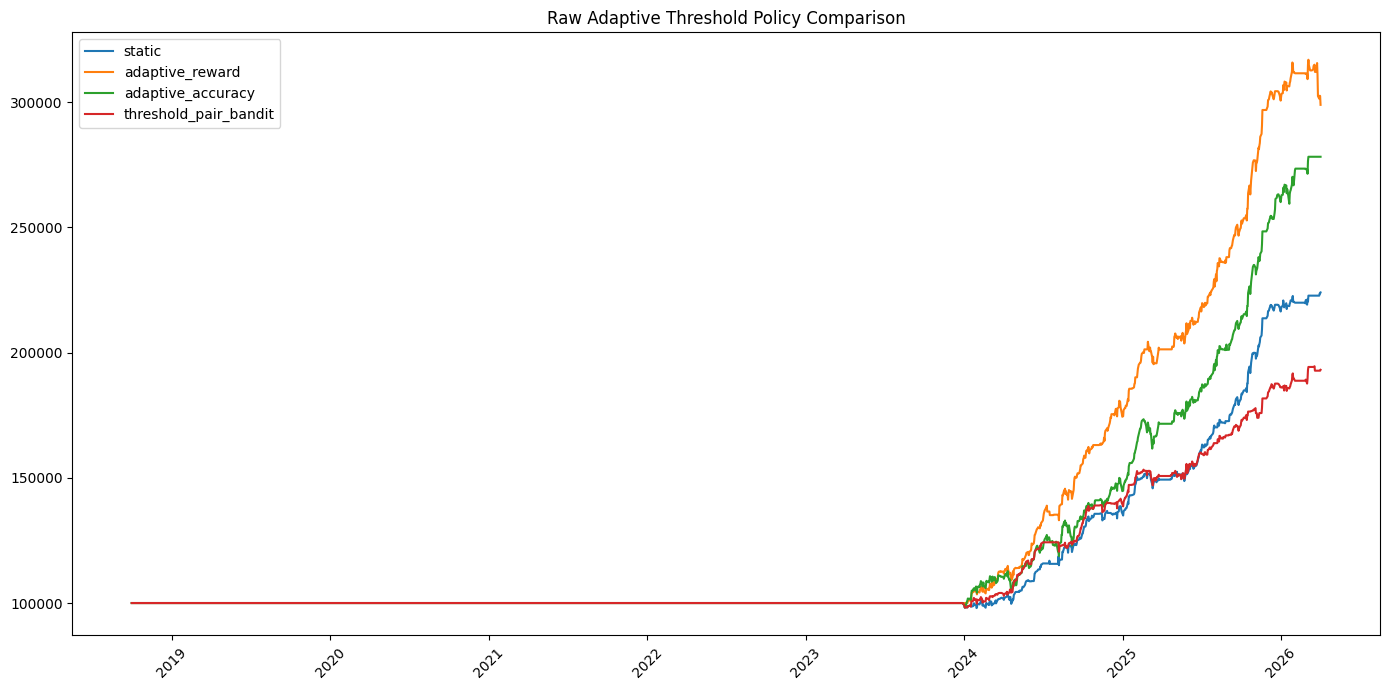

In [5]:
# ------------------------------------------------------------
# Equity comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))
for policy, res in results.items():
    daily_df = res['daily_log_df'].copy()
    if daily_df.empty:
        continue
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    plt.plot(daily_df['date'], daily_df['equity'], label=policy)

plt.legend()
plt.title('Raw Adaptive Threshold Policy Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

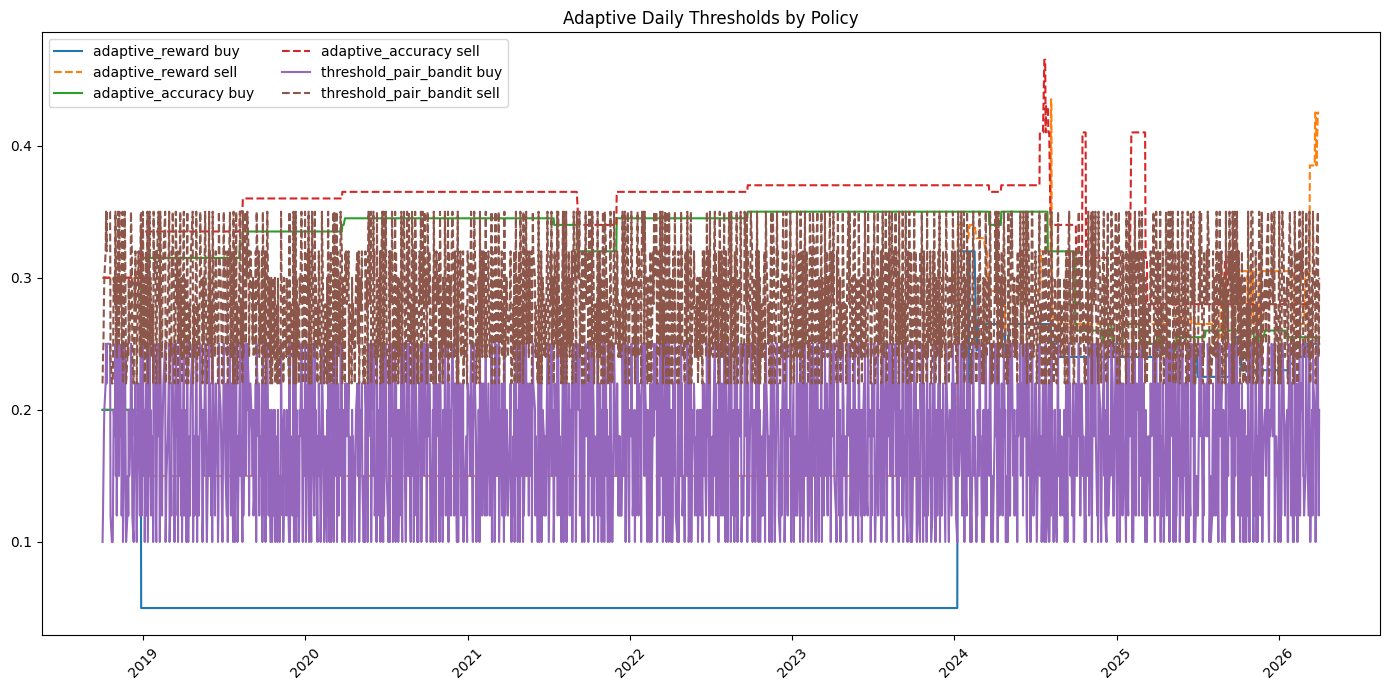

In [6]:
# ------------------------------------------------------------
# Threshold comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))
for policy, res in results.items():
    if policy == 'static':
        continue
    daily_df = res['daily_log_df'].copy()
    if daily_df.empty:
        continue
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    plt.plot(daily_df['date'], daily_df['daily_buy_level'], label=f'{policy} buy')
    plt.plot(daily_df['date'], daily_df['daily_sell_level'], label=f'{policy} sell', linestyle='--')

plt.legend(ncol=2)
plt.title('Adaptive Daily Thresholds by Policy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# ------------------------------------------------------------
# Action distribution comparison
# ------------------------------------------------------------

action_rows = []
for policy, res in results.items():
    reward_df = res['daily_reward_df']
    if reward_df.empty or 'chosen_action' not in reward_df.columns:
        continue
    counts = reward_df['chosen_action'].value_counts(normalize=True)
    action_rows.append({
        'policy': policy,
        'FORCE_BUY': float(counts.get('FORCE_BUY', 0.0)),
        'FREE': float(counts.get('FREE', 0.0)),
        'FORCE_SELL': float(counts.get('FORCE_SELL', 0.0)),
    })

action_df = pd.DataFrame(action_rows)
action_df

,policy,FORCE_BUY,FREE,FORCE_SELL
0,static,0.484093,0.374337,0.141569
1,adaptive_reward,0.190880,0.223224,0.585896
2,adaptive_accuracy,0.865854,0.046129,0.088017
3,threshold_pair_bandit,0.345175,0.447508,0.207317


In [8]:
# ------------------------------------------------------------
# Save comparison summary
# ------------------------------------------------------------

save_dir = Path('output') / 'adaptive_threshold_compare'
save_dir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(save_dir / 'summary.csv', index=False)
action_df.to_csv(save_dir / 'action_distribution.csv', index=False)

payload = {
    'policies': policies,
    'summary_rows': summary_df.to_dict(orient='records'),
}
with open(save_dir / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2)

str(save_dir)

'output\\adaptive_threshold_compare'